# Analyze one SNEC model output
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [2]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import SNEC_output_parser, plot_vel_radius_at_time_t, plot_mass_radius, plot_v_radius_time, get_times, sci_to_latex, plot_LC, plot_rho_pfile
import astropy.units as u
import glob
from itertools import cycle
%load_ext autoreload
%autoreload 2


Hardcoded some constants


In [4]:
Data = "/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/" # "/home/mrenzo/Documents/Research/codes/SNEC-1.01/Data/" # "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.25d51/Data/" # s30VdJNL_0.33/bomb_final_e_1.0d51/Data/" # 
for c in glob.glob(Data+"*"): print(c)

/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/magnitudes.dat
/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/kappa_table.xg
/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/index_lumshell.dat
/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/velshock_index.dat
/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/He_1.xg
/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/H_2.xg
/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/tau.xg
/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/temp.xg
/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/eps.xg
/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/Ni_deposit_function.xg
/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/rho.xg
/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/density_profile.dat
/home

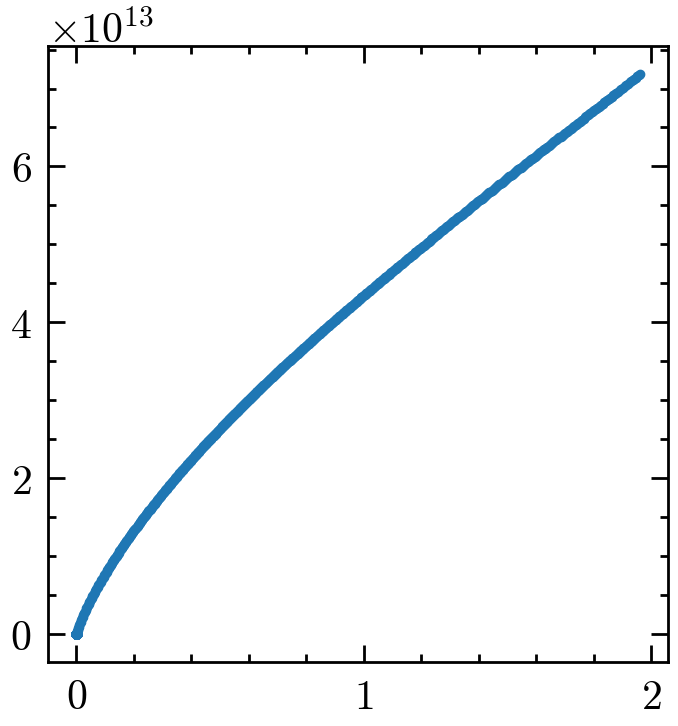

In [9]:
# find shock pos
shockpos = Data+'/velshock_index.dat'
shock_data = np.genfromtxt(shockpos)
i_shock = shock_data[:, 0]
t_shock = shock_data[:,1]*u.s
r_shock = shock_data[:,2]*u.cm
# with open(shockpos, "r") as f:
#     for i, l in enumerate(f):
#         print(l)

fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :])
ax.scatter(t_shock.to(u.d), r_shock)


[0.00000000e+00 1.80619365e+02 3.60548563e+02 5.40938146e+02
 7.20805617e+02 9.01354200e+02 1.08133438e+03 1.26087948e+03
 1.44148446e+03 1.62176422e+03 1.80075138e+03 1.98074867e+03
 2.16100722e+03 2.34076006e+03 2.52133695e+03 2.70149857e+03
 2.88170447e+03 3.06169088e+03 3.24120671e+03 3.42112860e+03
 3.60183992e+03 3.78183712e+03 3.96150666e+03 4.14153405e+03
 4.32197803e+03 4.50217022e+03 4.68153741e+03 4.86168493e+03
 5.04286405e+03 5.22273124e+03 5.40271474e+03 5.58337929e+03
 5.76377905e+03 5.94210628e+03 6.12359161e+03 6.30362113e+03
 6.48304856e+03 6.66314658e+03 6.84267539e+03 7.02454446e+03
 7.20459975e+03 7.38373714e+03 7.56424393e+03 7.74402817e+03
 7.92291420e+03 8.10401601e+03 8.28497061e+03 8.46417308e+03
 8.64528146e+03 8.82460431e+03 9.00315115e+03 9.18449264e+03
 9.36312509e+03 9.54328830e+03 9.72340284e+03 9.90461988e+03
 1.00850030e+04 1.02631516e+04 1.04427504e+04 1.06227607e+04
 1.08040175e+04 1.09851720e+04 1.11648259e+04 1.13431409e+04
 1.15241383e+04 1.170264

Text(0, 0.5, 'radius [cm]')

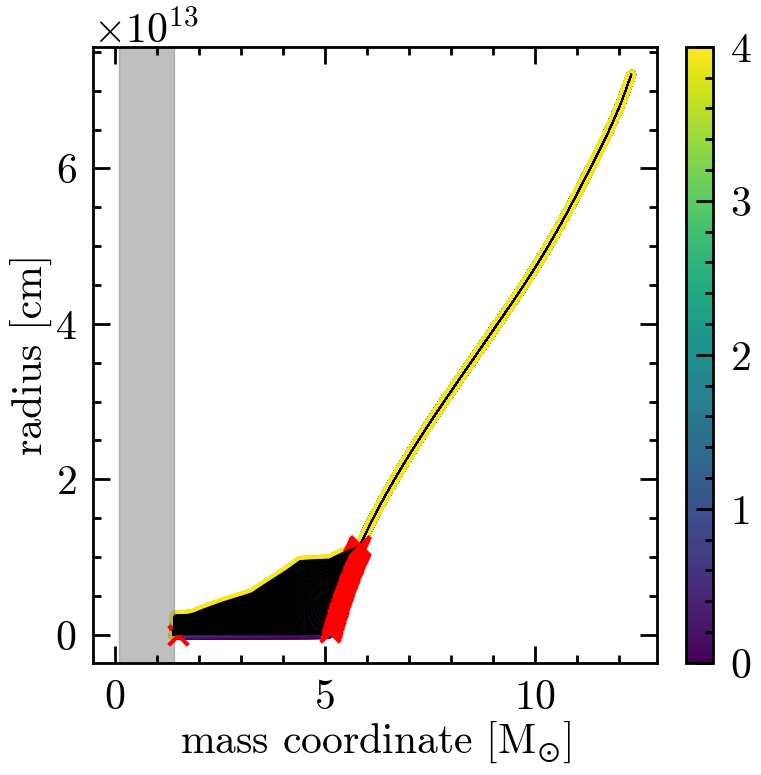

In [15]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])
cax = fig.add_subplot(gs[:, 105:])

bomb_spread = 0.1 *u.Msun #  see parameters file
# colors = plt.cm.Set2(np.linspace(0,1,len(models)))
mass_file = Data+'/mass.xg'
times = get_times(mass_file)
print(times)
# times = [times[0], times[int(len(times)/2.)], times[-1]]
for i, t in enumerate(times):
    if t.to(u.h)>=4*u.h: break 
    # print(i)
    m, r, p = plot_mass_radius(t, mass_file, ax=ax, # alpha=0.5, # s=10*(1+i),
                               # c=colors[j],
                               ls='-',
                               label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=4)
    j = np.argmin(np.absolute(t_shock-t))
    j_shock = int(i_shock[j])
    ax.scatter(m[j_shock].to(u.Msun), r[j_shock], c='r',  zorder=10, marker='x', s=200)
    xmin = min(m.to(u.Msun))

plt.colorbar(p, cax=cax)
# ax.legend(frameon=True, ncol=2, columnspacing=0.5, handlelength=0.05, title="time [h]")
ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
# ax.set_xlim(0, 7.0)
# ax.set_ylim(-1, 2.7e12)
# ax.set_yscale('log')
ax.set_xlabel(r"mass coordinate [$M_{\odot}$]")
ax.set_ylabel(r"radius [cm]") #(r"$\log_{10}(r/\mathrm{cm})$")


/tmp/ipykernel_1318926/3777476492.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0, 0.5, '$\\log_{10}(L/\\mathrm{[erg\\ s^{-1}]})$')

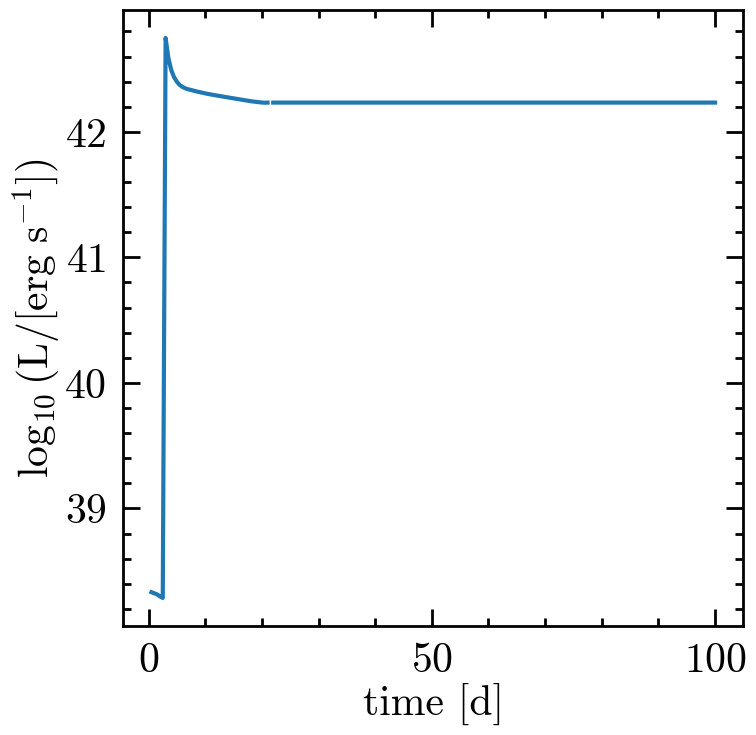

In [45]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])
lum_file=Data+'lum_observed.dat'
plot_LC(lum_file, ax=ax)
ax.legend()
ax.set_xlabel(r"time [d]")
ax.set_ylabel(r"$\log_{10}(L/\mathrm{[erg\ s^{-1}]})$")

FileNotFoundError: [Errno 2] No such file or directory: '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.25d51/Data//rho.xg'

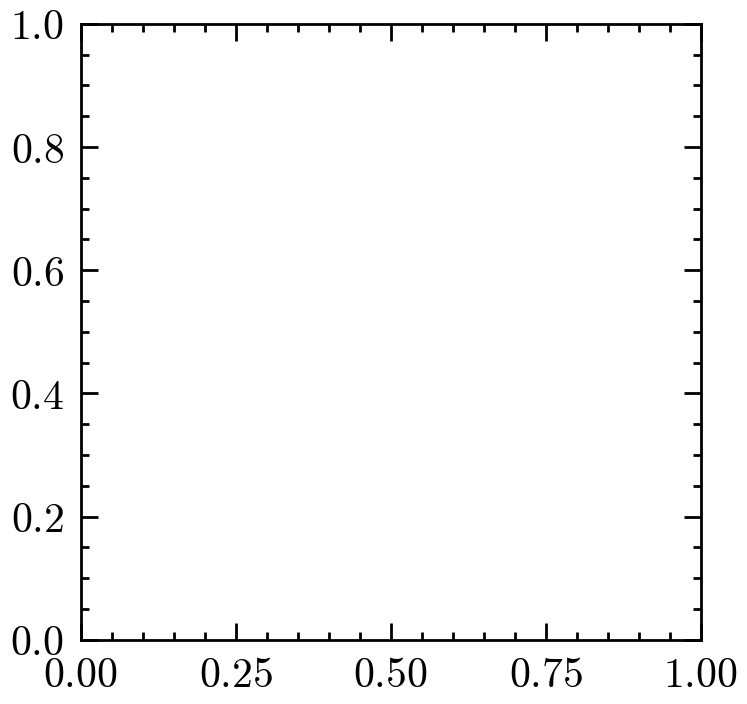

FileNotFoundError: [Errno 2] No such file or directory: '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.25d51/Data//rho.xg'

In [64]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])
rho_file = Data+'/rho.xg'
colors = plt.cm.viridis(np.linspace(0,1, 6))
# print(min(times), max(times))
for i, t in enumerate(times):
    # print(i)
    # print(t.to(u.h))
    if t.to(u.h) >= 72*u.h: break
    plot_rho_pfile(t, rho_file, ax=ax, c=colors[i]) 
ax.set_yscale('log')
ax.set_xlim(0, 3)

In [ ]:

  ! fix central radius
  r(1) = 1d6 ! 10 km = 1d6 cm = NS radius estimate, aka small
  cr(1) = 0.5d6